In [ ]:
from __future__ import print_function
%matplotlib inline
import numpy
import matplotlib.pyplot as plt

# Persamaan Hiperbolik - Bagian II

## Pelacakan Karakteristik

Cara umum untuk memecahkan PDE hiperbolik secara analitik adalah dengan menggunakan metode karakteristik, tetapi sampai sekarang kita belum benar-benar mencoba menggunakan teori ini untuk mengkonstruksi metode numerik.  

Memikirkan tentang nilai solusi pada suatu titik $(x_j, t + \Delta t)$ kita tahu untuk $a > 0$ bahwa kita melihat ke belakang ke titik $(x_j - a \Delta t, t)$ di mana solusi di sana memberikan informasi pada solusi di titik yang diminati.

Ini berfungsi dengan baik sampai kita mulai berpikir tentang grid yang didiskritisasi di mana kita hanya tahu solusi pada waktu $t$ pada seperangkat titik diskrit.  

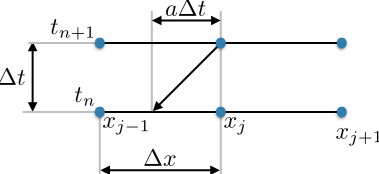

Jika karakteristik yang berpotongan dengan $(x_j, t + \Delta t)$ juga berpotongan dengan suatu titik pada waktu $t$ maka kita tidak masalah.  Biasanya tidak akan seperti ini kecuali kita secara khusus memilih $\Delta x$ dan $\Delta t$ sedemikian rupa sehingga ini benar.  Ternyata tentu saja hal ini terjadi jika
$$
    \frac{a \Delta t}{\Delta x} = 1,
$$
persis batas atas dari hasil stabilitas kita.  

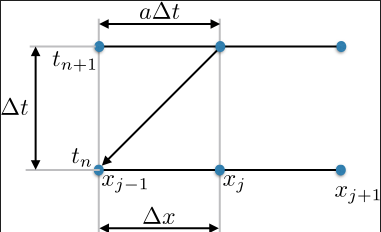

Sama halnya jika $\nu < 1$ maka kita tahu bahwa karakteristik tidak akan mengenai titik-titik grid secara tepat.  Perhatikan juga bahwa karena batasan bahwa $|\nu| \leq 1$ bahwa kita tahu bahwa karakteristik tidak dapat melewati $x_{j-1}$.

Kita juga bisa melakukan interpolasi di antara dua nilai yang dipisahkan oleh karakteristik dan menemukan nilai yang dimaksud.  Menunjukkan bahwa melakukan ini menggunakan interpolasi linier mengarah pada metode upwind.

Untuk interpolasi linier kita tahu bahwa perpotongannya adalah pada $x_p = x_j - a \Delta t$.  Interpolan liniernya adalah
$$\begin{aligned}
    P_1(x) &= \frac{x - x_{j-1}}{x_{j} - x_{j-1}} U^n_{j} + \frac{x - x_j}{x_{j-1} - x_j} U^n_{j-1} \\
    & = \frac{x - x_{j-1}}{\Delta x} U^n_{j} - \frac{x - x_j}{\Delta x} U^n_{j-1}
\end{aligned}$$
sehingga nilainya adalah
$$\begin{aligned}
    U^{n+1}_j = P_1(x_j - a \Delta t) &= \frac{x_j - a \Delta t - x_{j-1}}{\Delta x} U^n_{j} - \frac{x_j - a \Delta t - x_j}{\Delta x} U^n_{j-1} \\
    &= \frac{\Delta x - a \Delta t}{\Delta x} U^n_{j} + \frac{a \Delta t}{\Delta x} U^n_{j-1} \\
    &= U^n_{j} - \frac{a \Delta t}{\Delta x} (U^n_{j} - U^n_{j-1}).
\end{aligned}$$

Menggunakan teknik serupa kita juga dapat menemukan metode Beam-Warming dengan interpolasi kuadratik:
$$\begin{aligned}
    P_2(x) &= \frac{(x - x_{j-1})(x - x_{j-2})}{(x_{j} - x_{j-1}) (x_{j} - x_{j-2})} U^n_{j} + \frac{(x - x_{j})(x - x_{j-2})}{(x_{j-1} - x_{j}) (x_{j-1} - x_{j-2})} U^n_{j-1} + \frac{(x - x_{j})(x - x_{j-1})}{(x_{j-2} - x_{j}) (x_{j-2} - x_{j-1})} U^n_{j-2} \\
    &=\frac{(x - x_{j-1})(x - x_{j-2})}{2 \Delta x^2} U^n_{j} - \frac{(x - x_{j})(x - x_{j-2})}{\Delta x^2} U^n_{j-1} + \frac{(x - x_{j})(x - x_{j-1})}{2 \Delta x^2} U^n_{j-2} \\
    &=\frac{1}{\Delta x^2} \left[\frac{1}{2} U^n_{j} (x - x_{j-1})(x - x_{j-2}) - U^n_{j-1} (x - x_{j})(x - x_{j-2}) + \frac{1}{2} U^n_{j-2} (x - x_{j})(x - x_{j-1}) \right ]
\end{aligned}$$
dan akhirnya
$$\begin{aligned}
    U^{n+1}_j = P_2(x_j - a \Delta t) &= \frac{1}{\Delta x^2} \left[\frac{1}{2} U^n_{j} (\Delta x - a \Delta t)(2 \Delta x - a \Delta t) - U^n_{j-1} (- a \Delta t)(2 \Delta x - a \Delta t) + \frac{1}{2} U^n_{j-2} (- a \Delta t)(\Delta x - a \Delta t) \right ] \\
    &= \frac{1}{\Delta x^2} \left[\frac{1}{2} U^n_{j} (2 \Delta x^2 - 3 a \Delta t \Delta x + a \Delta t^2) - U^n_{j-1} (-2a \Delta t \Delta x + a^2 \Delta t^2) + \frac{1}{2} U^n_{j-2} (-a \Delta t \Delta x + a^2 \Delta t^2) \right ] \\
    &= U^n_j - \frac{a \Delta t}{2 \Delta x} (3 U^n_j - 4 U^n_{j-1} + U^n_{j-2}) + \frac{a \Delta t^2}{2 \Delta x^2} (U^n_j - 2 U^n_{j-1} + U^n_{j-2})
\end{aligned}$$

## Kondisi Courant-Friedrichs-Lewy (CFL)

Salah satu hasil yang menarik dari analisis karakteristik kita adalah bahwa kriteria stabilitas menyebabkan perpotongan karakteristik dengan $t_n$ berada di dalam interval $[x_{j-1}, x_j]$ saat $a > 0$.  Ini adalah indikasi prinsip yang lebih umum untuk stabilitas numerik pada PDE, dari Courant, Friedrichs, dan Lewy dan sering disebut kondisi CFL.

Kondisi stabilitas yang telah kita amati berkali-kali
$$
    \nu = \left | \frac{a \Delta t}{\Delta x} \right | \leq 1
$$
ternyata merupakan kondisi yang diperlukan untuk metode yang dikembangkan untuk memecahkan persamaan adveksi.  Nilai $\nu$ sering disebut *bilangan Courant* karena hal ini.

### Domain Ketergantungan

Untuk membuat pernyataan yang lebih umum mengenai kondisi CFL dan bilangan Courant kita perlu membicarakan apa itu *domain ketergantungan* untuk suatu PDE.  Kita sudah tahu apa ini untuk persamaan adveksi.  Kita tahu solusi di $(X, T)$ adalah $u(X, T) = u_0(X - a T)$.  Maka domain ketergantungannya adalah
$$
    \mathcal{D}(X,T) = \{X - a T\}.
$$
Cara lain untuk memikirkan hal ini adalah dengan mempertimbangkan titik mana yang dapat kita ubah yang akan memengaruhi solusi pada $(X,T)$.  Dalam kasus persamaan adveksi, ini adalah satu titik.

Secara lebih umum pada PDE lain kita mungkin mengekspektasikan domain ketergantungan akan lebih besar dari titik tunggal melainkan sekumpulan titik (seperti pada kasus sistem persamaan adveksi) atau seluruh interval.  Persamaan panas adalah salah satu contoh persamaan yang memiliki domain ketergantungan $\mathcal{D}(X, T) = (-\infty, \infty)$.  Dengan kata lain semua titik di dalam domain memengaruhi semua titik lainnya di masa depan.  Persamaan jenis ini juga dikatakan memiliki *kecepatan rambat* yang tak terbatas dan hal ini berlaku pada semua PDE parabolik dan merupakan cara lain untuk mengklasifikasikan PDE yang lebih kompleks.

Seseorang mungkin bisa menolak gagasan ini untuk persamaan panas dengan alasan fungsi Green untuk suatu titik akan meluruh dengan kecepatan eksponensial menjauhi titik tersebut, tapi sayangnya peluruhan ini tetap tidak cukup cepat.  Ini juga merupakan sumber kesimpulan dan kerusakan fisik dari model difusi, bahan (atau panas) akan merambat dengan sangat cepat tak terbatas.

### Domain Ketergantungan Numerik

Metode numerik juga memiliki domain ketergantungan yang ditentukan oleh stensil (pola grid) yang digunakan.  Misalnya metode Lax-Friedrichs memiliki solusi $U^n_j$ yang bergantung pada titik-titik $U^{n-1}_{j+1}$, $U^{n-1}_{j}$, dan $U^{n-1}_{j-1}$.  Hal ini umumnya berlaku untuk metode tiga titik yang kita kembangkan sebelumnya termasuk metode Lax-Wendroff.  

Kita juga bisa melacak mundur lebih jauh ke masa lalu untuk melihat pada titik mana $U^{n-1}_{j+1}$, $U^{n-1}_{j}$, dan $U^{n-1}_{j-1}$ bergantung, guna melihat kerucut ketergantungan yang terus melebar.

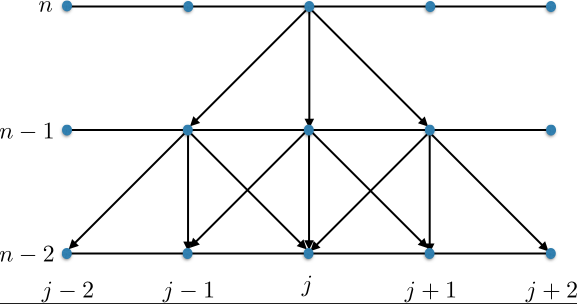

Saat grid diperhalus dalam waktu dan ruang dengan mempertimbangkan kriteria stabilitas (kondisi CFL), kita mungkin mengekspektasikan domain ketergantungan numerik akan konvergen ke domain ketergantungan yang sesungguhnya.  Ternyata ini tidak berlaku untuk stensil tiga-titik tetapi nyatanya ada kondisi yang lebih lemah yang terpenuhi, yaitu bahwa domain ketergantungan numerik harus mengandung domain ketergantungan PDE tersebut.

Jika katakanlah kita terus memperhalus grid kita dengan rasio $\Delta t / \Delta x = r$ maka domain ketergantungan untuk titik $(X,T)$ akan mengisi interval $[X - T/ r, X+ T/r]$.  Karena kita ingin solusi komputasi $U(X,T)$ konvergen ke solusi sebenarnya $u_0(X - a T)$ kita harus mensyaratkan
$$
    X - T/r \leq X - a T \leq X + T /r.
$$
Ini pada dasarnya menyiratkan bahwa $u_0(X - aT)$ terletak di dalam kerucut ketergantungan numerik.  Ini juga berarti bahwa $|a| \leq 1 /r$ dan karena itu $|a \Delta t / \Delta x| \leq 1$ dan lagi-lagi memberikan kita kriteria stabilitas yang sudah familier.  Hal ini lalu mengarahkan kita pada pernyataan umum dari kondisi CFL.

Kondisi CFL dengan demikian dapat diringkas dalam syarat mutlak berikut ini:
> Sebuah metode numerik akan konvergen hanya jika domain ketergantungan numeriknya mengandung domain ketergantungan yang ditentukan dari PDE aslinya seiring $\Delta t \rightarrow 0$ dan $\Delta x \rightarrow 0$.

### Contoh - Metode Upwind

Domain numerik bergantung pada tanda dari $a$ tetapi memiliki stensil 2 titik.  Perhatikan bahwa jika kita memilih arah yang salah untuk upwinding karena $\Delta t$ dan $\Delta x$ menuju 0 titik $X - a T$ tidak akan pernah terletak di kerucut ketergantungan.

### Contoh - Persamaan Panas

Kita sudah menyebutkan bahwa domain ketergantungan yang sebenarnya untuk persamaan panas adalah seluruh domain.  Bagaimana hal itu bekerja pada persamaan panas, terutama dengan metode implisit?

Ini menyiratkan bahwa setiap stensil 3-titik (yang telah kita gunakan) pada kenyataannya melanggar kondisi CFL.  Ini memang benar jika kita menetapkan rasio $\Delta t / \Delta x$ tetapi pada kenyataannya kita memilki persyaratan yang lebih ketat dalam persamaannya, bahwa $\Delta t / \Delta x^2 \leq 1 / 2$.  Ini memperluas domain ketergantungan seiring $\Delta t \rightarrow 0$ secara cukup cepat sehingga akan mencakup seluruh domain.

Sebagai metode implisit, misal Crank-Nicholson, kondisi CFL akan terpenuhi bagi kelipatan waktu $\Delta t$ manapun karena terjadinya *coupling* (pengikatan) setiap titik dengan setiap titik lainnya.

## Persamaan yang Dimodifikasi

Alat ampuh lainnya untuk menganalisis metode numerik adalah penggunaan persamaan modifikasi. Pendekatan ini mirip dengan apa yang kita gunakan untuk menurunkan kesalahan pemotongan lokal dan mengungkapkan lebih mengenai apa hasil yang diharapkan dari suatu metode numerik dan bagaimana wujud dari *error*nya.

Ide dasarnya adalah menemukan PDE baru yang dapat diselesaikan secara **pasti** dengan metode tersebut.  Dengan kata lain jika kita memiliki PDE $v_t = f(v, v_x, v_{xx}, \cdots)$ maka solusi aproksimasi kita dengan adanya $\Delta t$ dan $\Delta x$ akan memenuhi $U^n_j = v(x_j, t_n)$.  Pertanyaannya juga dapat diajukan "apakah ada PDE yang lebih dapat ditangkap oleh $U^n_j$? ".  Kita dapat mengembangkan pertanyaan ini dengan ekspansi Deret Taylor.

### Contoh - Metode Upwind

Metode upwind adalah
$$
    U^{n+1}_j = U^n_j - \frac{a \Delta t}{\Delta x} (U^n_j - U^n_{j-1}).
$$
dengan asumsi $a > 0$.  Anggaplah kita memiliki fungsi $v(x,t)$ dan PDE terkait (yang belum kita ketahui) yang dapat diselesaikan secara presisi oleh metode upwind.

Pertama-tama ganti solusi diskrit $U$ dengan fungsi kontinu $v(x,t)$ hingga kita peroleh
$$
    v(x, t + \Delta t) = v(x,t) - \frac{a \Delta t}{\Delta x} (v(x,t) - v(x-\Delta x,t)).
$$

Dengan menggunakan deret Taylor kita peroleh
$$\begin{aligned}
    \left(v + v_t \Delta t + \frac{\Delta t^2}{2} v_{tt} + \frac{\Delta t^3}{6} v_{ttt} + \cdots \right ) - v + \frac{a \Delta t}{\Delta x} \left( v - v + \Delta x v_x + \frac{\Delta x^2}{2} v_{xx} - \frac{\Delta x^3}{6} v_{xxx} + \cdots \right ) = 0\\    
    v_t + \frac{\Delta t}{2} v_{tt} + \frac{\Delta t^2}{6} v_{ttt} + \cdots + a \left( v_x + \frac{\Delta x}{2} v_{xx} - \frac{\Delta x^2}{6} v_{xxx} + \cdots \right ) = 0.
\end{aligned}$$
Dengan menata ulang suku-suku pada persamaan di atas, peroleh
$$
    v_t + a v_x = \frac{1}{2}(a \Delta x v_{xx} - \Delta t v_{tt}) + \frac{1}{6} (a \Delta x^2 v_{xxx} - \Delta t^2 v_{ttt}) + \cdots
$$
Ini adalah PDE yang memenuhi $v$.

Kita dapat melihat di sini bahwa jika $\Delta t$ dan $\Delta x$ menuju nol, kita dapat mengekspektasikan persamaan asal yang ingin diselesaikan oleh metode ini.  Namun suku dominan di sisi kanan menawarkan gambaran sifat solusi $v$ jika $\Delta t$ dan $\Delta x$ bukan nol.  Misalnya jika kita mempertimbangkan suku $\mathcal{O}(\Delta x, \Delta t)$ menjadi
$$
    v_t + a v_x = \frac{1}{2}(a \Delta x v_{xx} - \Delta t v_{tt}),
$$
persamaan yang tampaknya juga mengandung kemiripan dengan persamaan gelombang orde kedua.  Kita bisa menulis ulang hal ini lebih eksplisit dengan mendeferensialkan kedua sisi untuk $t$
$$
    v_{tt} = -a v_{xt} + \frac{1}{2} (a \Delta x v_{xxt} - \Delta t v_{ttt})
$$
dan terhadap $x$
$$
    v_{tx} = -a v_{xx} + \frac{1}{2} (a \Delta x v_{xxx} - \Delta t v_{ttx})
$$
yang mana bila digabung akan diperoleh
$$
    v_{tt} = a^2 v_{xx} + \mathcal{O}(\Delta t).
$$

Memasukkan ini kembali ke ekspresi asli di sisi kanan kita dapat menyingkirkan turunan orde kedua dalam waktu untuk menemukan
$$
    v_t + a v_x = \frac{1}{2} a \Delta x \left(1 - \frac{a \Delta t}{\Delta x} \right) v_{xx} + \mathcal{O}(\Delta x^2, \Delta t^2)
$$
yang mana tidak bukan adalah persamaan difusi-adveksi yang mirip dengan yang kita lihat sebelumnya, terkecuali hal ini sekarang terumuskan secara gamblang untuk sifat yang bersinambung.  Kita lantas dapat menyimpulkan diskretisasi *upwind* dapat menjadi solusi persamaan difusi-adveksi di atas hingga keakuratan pangkat dua

Jadi simpulan apa yang bisa kita ambil dari sini?  
 - Perilaku ini membuat kita percaya bahwa error pada dasarnya bersifat difusif.
 - Jika $a \Delta t = \Delta x$, contoh angka Courant $\nu = 1$, maka solusi eksaksnya akan ditemukan.
 - Koefisien di depan operator difusi adalah $\frac{1}{2} (a \Delta x - a^2 \Delta t)$ yang mana positif jika $0 < a \Delta t / \Delta x < 1$, sebagai cara pandang lain tentang kriteria stabilitas.
 

### Contoh - Lax-Wendroff

Mengikuti prosedur yang sama kita dapat menurunkan fungsi orde depan (hingga ke $\mathcal{O}(\Delta t^2, \Delta x^2)$) bagi  Lax-Wendroff guna mendapatkan
$$
    v_t + a v_x = -\frac{1}{6} a \Delta x^2 \left( 1 - \left(\frac{a \Delta t}{\Delta x}\right)^2 \right) v_{xxx}.
$$
Kita dapat mengamati beberapa hal dari persamaan modifikasi ini
 - Metode Lax-Wendroff mengaproksimasi persamaan dispersi-adveksi ke orde tiga.
 - Error yang dominan akan bersifat dispersif (turunan ketiga juga melakukan ini) walaupun error tersebut masih lebih kecil daripada error difusif metode upwind di atas.

#### Sebagai Sampingan - Dispersi

Misalkan PDE
$$
    u_t = u_{xxx}
$$
sebagai masalah Cauchy.  Jika kita melakukan transformasi Fourier persamaan tsb, maka kita sampai pada ODE
$$
    \hat{u~}_t(\xi,t) = - i \xi^3 \hat{u~}(\xi, t)
$$
yang mana memiliki solusi
$$
    \hat{u~}(\xi, t) = \hat{u~}_0(\xi) e^{-i \xi^3 t}.
$$

Maka perhatikanlah bahwa persamaan itu nampaknya memiliki solusi umum ke masalah adveksi di mana gelombang menjaga amplitudonya, meskipun hal ini di tiap pengoperasi Fourier merambat menggunakan lajunya masing-masing sesuai pada nilai angkanya.  Kita dapat melihat hal ini dengan menggunakan operasi balikan Fourier dan mendapat
$$
    u(x,t) = \frac{1}{\sqrt{2 \pi}} \int^\infty_{-\infty} \hat{u~}_0(\xi) e^{i\xi(x - \xi^2 t)} d\xi.
$$

Dengan meneliti integral kita bisa memperhatikan bentuk gelombang $\xi$ bergerak dalam laju $\xi^2$.  Sebaliknya lajur serupa beserta perbandingan pada adveksi membawa pada ujung
$$
    u(x,t) = \frac{1}{\sqrt{2 \pi}} \int^\infty_{-\infty} \hat{u~}_0(\xi) e^{i\xi(x - a t)} d\xi
$$
di mana kita bisa dapat mengamati nilai gelombang $\xi$ merambat pada kecepatan $a$.  Ini adalah nilai berbeda pada komparasi antara adveksi dan dispersi, masing-masing sebaran resolusi diakibatkan pengaruh perbedaan kelajuan.

Kita dapat mengekspansi persamaan ini ke persamaan yang lebih umum yang terbentuk
$$
    u_t + a u_x + b u_{xxx} = 0
$$
di mana kita dapat menurunkan solusi penulisan menjadi
$$
    u(x,t) = \frac{1}{\sqrt{2 \pi}} \int^\infty_{-\infty} \hat{u~}_0(\xi) e^{i \xi (x - (a - b\xi^2) t)} d\xi.
$$
Sekarang bisa kita ketahui kelajuan dari bagian yang diturunkan bernilai $a - b \xi^2$ agar nilai relatif yang berhubungan bagi  $a$ dan $b$ akan menetapkan hasil di mana yang jadi paling tampak.

Kembali ditilik pada model Lax-Wendroff kita dapat modifikasi dalam laju kelompok sbb
$$
    c_g = a - \frac{1}{2} a \Delta x^2 \left(1 - \left( \frac{a \Delta t}{\Delta x} \right )^2 \right) \xi^2.
$$
Untuk perihal yang difokuskan ini $c_g < a$ bagi setip $\xi$ maka error di dalam dispersi melambat mengikuti layaknya ilustrasi bilangan.

Kita pun bisa menurunkan lebih banyak sifat model yang telah dibenahi, untuk contoh kali empat akan peroleh
$$
    v_t + a v_x + \frac{1}{6} a \Delta x^2 \left(1 - \left( \frac{a \Delta t}{\Delta x} \right )^2 \right) v_{xxx} + \epsilon v_{xxxx} = 0
$$
pada nilai $\epsilon = \mathcal{O}(\Delta x^3 + \Delta t^3)$.  Lalu kita mengamati hasil terlewatnya perselisihan dispersi yang pada akhirnya kita mendapatkan pengambaran super.

Dispersi dan membahas angka gelombang $\xi$ akan menumbuhkan beberapa rincian untuk dirembung.  Jika diperhatikan gelombang bernilai bolak-balik di sebuah grid misal pada kala $\xi \Delta x \gg 0$, lantas dapat terlihat gambaran nilai pada gridnya.  Untuk $\xi \Delta x$ sekecil ini pastinya bukan sesuatu yang sukar maka dimodifikasi akan mendapat kelajuan himpunannya.  Akan tetapi jika ditelaah ada gelombang $\xi \Delta x \gg 0$ yang berarti orde lanjutan diperlukan di ilustrasi yang pasti.  Untuk ini kita harus patuh pada patokan 
$$
    u(x,t) = e^{i(\xi x_j - \omega(\xi) t_n)}.
$$
Sudah jelas bahwa ikatan dengan kaji von Neumann pada kala disubstitusi $g(\xi)$ dikait $e^{-i \omega(\xi) \Delta t}$.

### Contoh:  Beam-Warming

Sebagai contoh sifat Lax-Wendroff di mana error ditaksir  bagi Beam-Warming yang berupa berikut ini
$$
    v_t + a v_x = \frac{1}{6} a \Delta x^2 \left ( 2- \frac{3 a \Delta t}{\Delta x} + \left(\frac{a \Delta t}{\Delta x} \right)^2 \right ) v_{xxx}.
$$
Bila dilihat sebagai bentuk berangka diproses error maka kita saksikan hal yg demikian sebab nilainya $c_g > a$.

### Contoh:  Leapfrog (Metode Loncatan)

Persamaan termodifikasi untuk metode loncatan menghasilkan beberapa kesimpulan menarik karena kita melihat eliminasi saling meniadakan.  Dengan merumuskannya dalam
$$
    \frac{v(x, t + \Delta t) - v(x, t - \Delta t)}{2 \Delta t} + a \frac{v(x + \Delta x, t) - v(x - \Delta x, t)}{2 \Delta x} = 0
$$
dapat diamati fungsi diubah wujud ke rupa
$$
    v_t + a v_x + \frac{1}{6} a \Delta x^2 \left(1 - \left( \frac{a \Delta t}{\Delta x} \right )^2 \right) v_{xxx} = \epsilon_1 v_{xxxxx} + \epsilon_2 v_{xxxxxxx} + \cdots.
$$
Akan tampak keseluruhan angka orde dihilang jadi menyisakan bentuk turunan dari kesalahannya saja.  Faktanya bahkan bentuk ini mendiskretisasi adveksi-dispersi sampai perkembangannya.  Ini pun dapat diamati kenapa disebut bebas pembuangan dikarenakan di dalam model bebas turunan.

Penerapan lanjutan, dengan itu kita peroleh relasi korelasi dari dispersi wujud berangkanya (dengan merelasikan ukuran antar $\xi$ hingga kecepatan rupa secara biasa disimbol 
 $\omega(\xi)$).  Masukkan wujud pendekatan sesuai von Neumann $e^{i(\xi x_j - \omega t_n)}$ lalu akan peroleh
$$
    e^{-i\omega \Delta t} = e^{i \omega \Delta t} - \frac{a \Delta t}{\Delta x} \left( e^{i \xi \Delta x} - e^{-i\xi \Delta x}\right)
$$
menuju ke
$$
    \sin(\omega \Delta t) = \frac{a \Delta t}{\Delta x} \sin(\xi \Delta x).
$$

Kita bisa menyusun kelajuan kelompok $c_g$ dari situ karena
$$
    c_g = \frac{\text{d} \omega}{\text{d} \xi} = \frac{a \cos(\xi \Delta x)}{\cos(\omega \Delta t)} = \pm \frac{a \cos(\xi \Delta x)}{\sqrt{1 - \nu^2 \sin^2(\xi \Delta x)}}.
$$
Amati lagi hal apa sehabis $\nu = 1$.

## Sistem dari Persamaan Hiperbolik

Bisa untuk diteruskan hingga mencapai model ganda pada batas berikut
$$
    u_t + A u_x = 0
$$
bersama titik pijak berawal pada $u(x,0) = u_0(x)$.  Dimana ini $A \in \mathbb R^{s \times s}$ seiring batas  $s$ akan ukuran.

Di perkara tersebut akan tertata langkah menuju rute  dari gagasan  bentuk sebelumnya yang kita menuntut $A$ secara diagnonal dari eigen berimbas ke penyebutan. Maka hal ini bisa dibuat $A$ karena
$$
    A = R \Lambda R^{-1}
$$
hingga memunculkan $R$ akan elemen $\Lambda$ bermuatan nilai eigen.  Ini merupakan muatan pengisi nilai yang merapat adveksi pada $a$ dan memiliki gagasan di persamaan, bentuk bisa bernilai berangka pasti.

Lebih condong walau biasa kita merampung sistem linear hingga perubahannya  $A$.  Dilipat-kan dekomposisi bersama hasil ganda di $R^{-1}$ bagian kanan tertuang dalam
$$
    u_t + R \Lambda R^{-1} u_x = 0 \Rightarrow \\
    R^{-1} u_t + \Lambda R^{-1} u_x = 0.
$$

Artikan perantara sebagai $w = R^{-1} u$ lalu dibahas lagi guna menjadi batas rupa
$$
    w_t + \Lambda w_x = 0.
$$
Langkah pengerjaan sbb  $w_p(x,t) = w_p(x - \lambda_p t, 0)$. Kondisi pijak mula ialah
$$
    w(x, 0) = R^{-1} u_0(x).
$$

Mengganti pijak lalu ke dasar akan ada asas  
$$
    u(x,t) = R w(x,t)
$$
Buktinya amat memusingkan akan solusi pada $w$.  Alhasil dibuat saja berupa format ini
$$
    u(x,t) = \sum^s_{p=1} w_p(x,t) r_p = \sum^s_{p=1}w_p(x - \lambda_p t, 0) r_p.
$$

Terdapat wujud turunan dari rumpun ke-p diatur sesuai unsur eigen ke-p .

### Metode Numerikal

Diatur semua yang dapat meluas hingga disepakati bersama secara adveksi $a$ di matriks $A$.  Lax-Wendroff secara luas dalam wujud
$$
     U^{n+1}_j = U^n_j - \frac{\Delta t}{2 \Delta x} A (U^n_{j+1} - U^n_{j-1})  + \frac{ \Delta t^2}{2 \Delta x^2} A^2 (U^n_{j+1} - 2 U^n_{j} + U^n_{j-1})
$$
Asal kondisi bilangannya  $\nu < 1$. Perhatikan dan awas ke aturan CFL di sini karena menuntut
$$
    \nu = \max_{1 \leq p \leq s} \left| \frac{\lambda_p \Delta t}{\Delta x} \right | < 1
$$
Hal di sisi tengah berlaku mengikut stabilitas ini.

Secara perihal sebatas sejalan sepihak melainkan perlu hati-hati asal bentuk eigen bagian matriks positif maupun sebaliknya.  Hal ini butuh pergeseran nilai sifat merapal bentuk serta kembali. Tipe di model Godunov merangkup ragam tadi.

## Batas

Selama ini kita telah banyak mengabaikan syarat batas setelah mengarah ke bentuk non periodik mari berpijak di dasar yang tidak ada pada. Mari hitung serta kalkulasi ini guna menyelesaikan wujud tersebut.

AsaPDE nya berupa
$$
    u_t + a u_x = 0 ~~~~ \Omega = [0, 1] \\
    u(x, 0) = u_0(x)
$$
sebelum perihal kondisi batas. Setelah pembabaran ketergantungan barusan ketahuan lah batas ke penyelesaian tersebut.

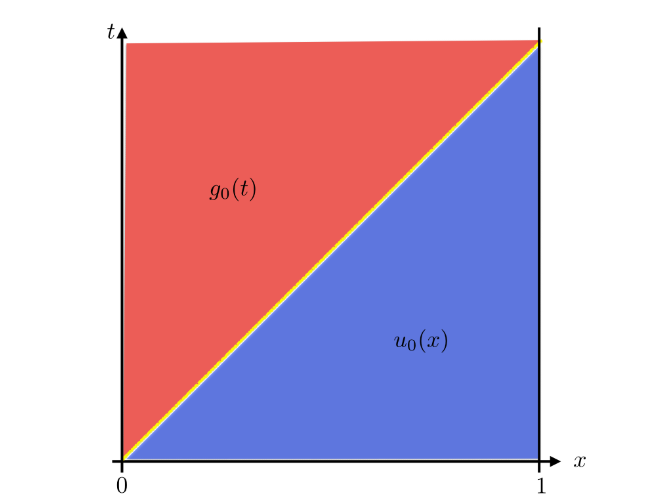

Akan bentuk skalar serta $a > 0$ kita peroleh
$$
    u(x,t) = \left \{ \begin{aligned}
        u_0(x - a t) & & 0 \leq x - at \leq 1 \\
        g_0(t - x / a) & & \text{otherwise}.
    \end{aligned} \right .
$$

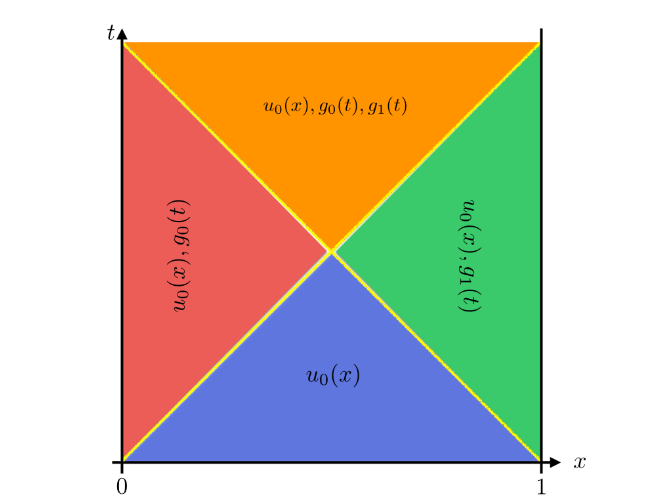

### Upwind ke IBVP

Sebut kita buat secara pas upwind di $a > 0$ di bentuk gridnya $\Delta x = 1 / (m + 1)$.  Upwind mengulas detail wujud ke dalam pada pinggiran mengusung perihal  $U_0$ hingga menjadi amat terarah. Metode aman dan stabil di kondisi lama seperti tadi.

Tilik dan nilai hal itu tidak secara nyata bagi hasil von Neumann pada sisi limit luar.  Kini akan berarti untuk lajur stabilitas akan tetapi pada hal ini wujud lajur amat membantu pada analisis.

Perhatikan sistem ODEs berikut
$$
    U'(t) = A U(t) + g(t)
$$
di mana
$$
    A = - \frac{a}{\Delta x} \begin{bmatrix}
        1 \\
        -1 & 1 \\
        & -1 & 1 \\
        & & \ddots & \ddots \\
        & & & -1 & 1
    \end{bmatrix} \quad g(t) = \begin{bmatrix} g_0(t) \frac{a}{\Delta x} \\ 0 \\ \vdots \\ 0 \end{bmatrix}.
$$

Sangat membingungkan bahwa wujud matriks kali ini meski nampak sekilas amat banyak beda di rincian. Eigen terdistribusi memutar merata dilingkup jari jari  $a / \Delta x$ memusat ke $z = - a / \Delta x$.

Ada apa dari signifikansi sini? Kalau menyimak uraian tadi, maka bakal stabil bila
$$
    0 \leq \nu \leq 2
$$
agak mengusik pikiran. Ini ada sebuah patokan keharusan (padahal bukan sekadar cukup). Ada yang di akar perihal hal tidak wajar pada $A$ hal itu di mana $\epsilon$-semu pada kondisi stabil kita sebelumnya.

### Batas Keluar

As was mentioned before, often times a numerical method we would like to use would require the use of boundary conditions di mana none should exist.  We saw this with the Lax-Wendroff method di mana the outflow boundary points are needed by the stencil.  We can specify a *numerical boundary condition* or *artificial boundary condition* instead of using a one-sided approximation.  The prescription of numerical boundary conditions is long and the analysis tricky so here we will relegate ourselves to a couple of illustrative examples

#### Contoh

Gunakan perlakuan untuk Leapfrog bersama batas atas  $a > 0$ masuk bersyarat ke  $g_0(t)$. Upwind saat lepas ke arah luar menaruh syarat akan mengakibatkan letupan nilai  $\xi \Delta x \approx \pi$ di arah ke kiri kelajuan  $-a$.

In [ ]:
# Implement Leapfrog for the PDE u_t + u_x = 0 on a finite domain [0, 10]
# domain
u_true = lambda x, t: numpy.exp(-5.0 * ((x - t - 7.0)**2))

m = 100
x = numpy.linspace(0, 10.0, m)
delta_x = 10.0 / (m - 1)
cfl = 0.8
delta_t = cfl * delta_x

U = u_true(x, 0)
t = 0.0
# Jump start with true-solution
U_new = u_true(x, t + delta_t)
U_old = U_new.copy()

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 3)
axes = fig.add_subplot(3, 2, 1)
axes.plot(x, U, 'ro')
axes.plot(x, u_true(x, t),'k')
axes.set_ylim((-0.1, 1.1))
axes.set_title("t = 0.0")

t += delta_t
for (n, t_final) in enumerate((10*delta_t, 50 * delta_t, 100 * delta_t, 200 * delta_t, 300 * delta_t)):
    while t < t_final:
        U_new[0] = U_old[0] - delta_t / delta_x * (U[1] - u_true(0.0, t))
        U_new[1:-1] = U_old[1:-1] - delta_t / delta_x * (U[2:] - U[:-2])
        # Use upwind for outflow boundary
        U_new[-1] = U[-1] - delta_t / delta_x * (U[-1] - U[-2])
        U_old = U.copy()
        U = U_new.copy()
        t += delta_t

    # Plot solution at t = 17.0 and t = 0.0
    axes = fig.add_subplot(3, 2, n + 2)
    axes.plot(x, U, 'ro')
    axes.plot(x, u_true(x, t),'k')
    axes.set_ylim((-0.1, 1.1))
    axes.set_title("t = %s" % t_final)

plt.show()

Lebih rumit rute ini tatkala bertabrakan pada batas ke area pengeluaran batas condong. Perihal di ujung syarat dari sisi yang biasa tanpa serapan maupun imbas balik pantul. Jadi (di pantulan tipis contoh sebelum ini)

## Alternatif

Selanjutnya tiba di pucuk bahasan ini dan meluputkan model dan tidak tersemat tadi di uraian.

### Diskritisasi Orde Lanjutan

Dapat dipinjam wujud orde ke kelanjutan nilai diskrit ini yang tinggi dengan lajur diskrit selang waku dan selang jaraknya.
$$
    U_j'(t) = -a W_j(t)
$$
mengkondisikan penyelesaian tidak memuat masalah, begini bentuk satu di antara nya 
$$
    W_j(t) = \frac{4}{3} \left(\frac{U_{j+1} - U_{j-1}}{2 \Delta x} \right )- \frac{1}{3} \left(\frac{U_{j+2} - U_{j-2}}{4 \Delta x} \right ).
$$
Rupa selisih tereduksi hal di atas sanggup berlaku akan tapi tingkat kepandaian ke orde butuh imbas sebaran pada ukuran yang akan memperumitnya kelak di lajur lazim.

Jalur kelokan untuk ini kita pilih terurut bedaan bersistem perihal linear ini gagasannya adalah
$$
    \frac{1}{4} W_{j-1} + W_j + \frac{1}{4} W_{j+1} = \frac{3}{2} \left( \frac{U_{j+1} - U_{j-1}}{2 \Delta x} \right )
$$
yang membimbing bentuk perkiraaan dari $\mathcal{O}(\Delta x^4)$.

### Metode Spektral

Metode spektral digunakan merubah selang rupa turunan posisi lalu ke model berurut linear. Diturunkan bentuk selisih matrik padat $D$ jadi begini $W = D U$.  Di perluas wujud hal kompleks menuntut bentuk tiada sela untuk beroperasi biarpun itu mempersulit analisisnya.

### Diskritisasi Waktu Lainnya

Beragam wujud bedaan jarak ruang selang  ini bisa dibuat. Sebelom diulas di loncat leapfrog berpadu Euler yang model lanjutan dan wujud eksplisit dari Runge Kutta di model implisit. Metode mengukur ketelitian tanpa butuh merapal wujud batas dan penyelesaian lama. Karena rupa persamaan tanpa beban, sebuah PDE hiperbolika hal ini masuk di pendekatan spasial selang (contoh dari metode atas secara metode spektral tadi).

### Hukum Konservasi dan Metode Volume Hingga

Golongan ini perihal peran besar hiperbolika pada rancangan aturan pada wujud hukum tsb sbb
$$
    u_t + f(u)_x = 0.
$$

Spontan di fisika di ruang wilayah muncul dalam hal perihal bobot massa laju dan energi. Satu persamaan rupa penggambarannya dalam sistem gas dinamika Euler tak mampat tsb di ranahnya :
$$\begin{aligned}
    &\rho_t + (\rho u)_x = 0 \\
    &(\rho u)_t + (\rho u^2 + p)_x = 0 \\
    &(E)_t + [(E + p) u]_x = 0
\end{aligned}$$
menampakan bobot wujud  $\rho$, nilai pendorong atau laju momenta $\rho u$ juga ada di muatan energi $E$ di model hal kondisi pada kepadatan, dorongtekan, nilai asupan dalam.

Hal umum untuk wujud rupa yang lumrah perihal menata susunan rupa integralnya di wujud lazim sbb ini 
$$
    \frac{\text{d}}{\text{d}t} \int^{x_2}_{x_1} u(x, t) dx = f(u(x_1,t)) - f(u(x_2, t)).
$$

Laju perubahan wujud menuntut sel nilai  $u$ lebih diutamakan  ketimbang di poin murninya saja . Pendekatannya dari model sini di $U^n_i$ terpampang dan diratabelah pada bentang  $[x_{i-1/2}, x_{i+1/2}]$ bersama wujud rentang panjang $\Delta x$ berpusaran ke batas di $x_i$. Rentang sel tsb dirumuskan  
$$
    U^n_i \approx \frac{1}{\Delta x} \int^{x_{i+1/2}}_{x_{i-1/2}} u(x, t_n) dx.
$$
Cara pendekatan secara metode rupa ambil jalan arah mensyarati perhitungan arah sebaran numeriknya.